# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Sienna Joya Haag
* Username: sjhaag
* Student number: S6214320
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

$$\sigma_g = \sqrt{\left(\frac{4\pi^2}{T^2}\sigma_L\right)^2+\left(\frac{-8\pi^2L}{T^3}\sigma_T\right)^2}$$

$$\sigma_g \approx 0.2176 \approx 0.22\ ms^{-2}$$
$$g = (9.77 \pm 0.22)\ ms^{-2}$$

In [7]:
import numpy as np
L = np.random.normal(1, 0.01, 10000) # Randomly sampling 10000 values for L from a normal distribution centered at 1.00, with standard deviation 0.01
T = np.random.normal(2.01, 0.02, 10000) # Randomly sampling 10000 values for T from a normal distribution centered at 2.01, with standard deviation 0.02
g = 4*np.pi**2*L/(T**2) # Calculating the distribution of g as given by the formula for g
print(f"g = ({round(np.mean(g), 5)} +- {round(np.std(g), 5)}) ms^-2") # Calculating g and its uncertainty

g = (9.77017 +- 0.21744) ms^-2


Both methods give the same answer, when rounded to an appropriate number of significant figures, showing that monte carlo error propagation is a good estimate for error propagation.

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 3

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    You need to show more significant digits and use a higher N for the monte carlo implementation
</div>

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
import numpy as np
import cmath
a = float(input("Please enter a value for a: "))
b = float(input("Please enter a value for b: "))
c = float(input("Please enter a value for c: "))

print(f"y = {a}x^2 + {b}x + {c} = 0")

d= b**2 -4*a*c # Calculating the determinant

# Determining whether there are two real, one real, or no real solutions, and printing those that are found.
if d>0:
    x1= (-b +np.sqrt(d))/(2*a)
    x2= (-b -np.sqrt(d))/(2*a)
    print(f"The two roots are x = {x1} and x = {x2}")
    if np.isclose(a*x1**2 + b*x1 + c, 0) and np.isclose(a*x2**2 + b*x2 + c, 0): 
        print("Double checked, it works!")
    else:
        print("Double checked and I made a mistake, sorry! These solutions do not work.")
elif d==0:
    x = -b/(2*a)
    print(f"There is one solution: x = {x}")
    if np.isclose(a*x**2 + b*x + c, 0):
        print("Double checked, it works!")
    else:
        print("Double checked and I made a mistake, sorry! This solution does not work.")
else:
    x1 = -b/(2*a) + (np.sqrt(d*-1)*1j)/(2*a)
    x2 = np.conj(x1)
    print(f"The two roots are complex: x = {x1.real} + {x1.imag}i and x = {x1.real} - {x1.imag}i")
    if np.isclose(a*x1**2 + b*x1 + c, 0+0j) and np.isclose(a*x2**2 + b*x2 + c, 0+0j):
        print("Double checked, it works!")
    else:
        print("Double checked and I made a mistake, sorry! These solutions do not work.")

Please enter a value for a: 6
Please enter a value for b: 7
Please enter a value for c: 8
y = 6.0x^2 + 7.0x + 8.0 = 0
The two roots are complex: x = -0.5833333333333334 + 0.9965217285917831i and x = -0.5833333333333334 - 0.9965217285917831i
Double checked, it works!


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 3

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    The dubble checking doesn't work correctly. Use np.isclose instead
</div>

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

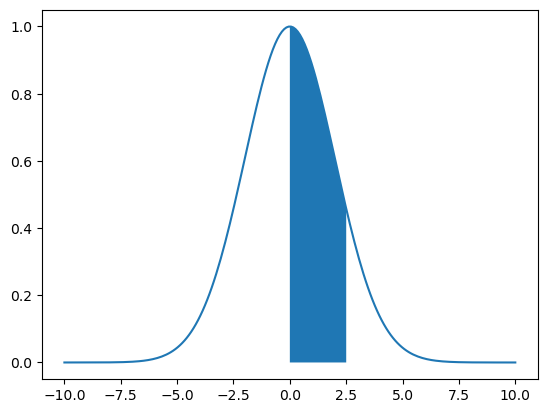

The area between x = 0 and x = 2.5 is: 1.9769788548675902
The total area under the graph is: 5.013256549262001


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
A = 1.0      # Peak amplitude
x0 = 0.0     # Center of the Gaussian
sigma = 2.0  # Width (standard deviation)
z0 = 0.0     # Vertical offset


x = np.linspace(-10, 10, 200) # Generate x values for plotting the full curve
f = gauss(x, A, x0, sigma, z0) # Computing Gaussian values for the full range
plt.plot(x, f) 

x1 = np.linspace(0, 2.5, 200) # Generate x values for the shaded region (0 to 2.5)
f1 = gauss(x1, A, x0, sigma, z0) # Computing Gaussian values in that region

# Fill the area under the curve between x=0 and x=2.5
plt.fill_between(x1, f1, 0)
plt.show()

# Numerically integrating the Gaussian between x=0 and x=2.5
a, ae = sp.integrate.quad(gauss, 0, 2.5, args=(A, x0, sigma, z0)) # a, ae to seperate the value and error

print(f"The area between x = 0 and x = 2.5 is: {a}")

# Integrating to get the total area
b, be = sp.integrate.quad(gauss, -np.inf, np.inf, args=(A, x0, sigma, z0))

print(f"The total area under the graph is: {b}")

$$ A \sigma \cdot \sqrt {2\pi} \approx 5.013 $$

The area calculated is the same using both methods. 

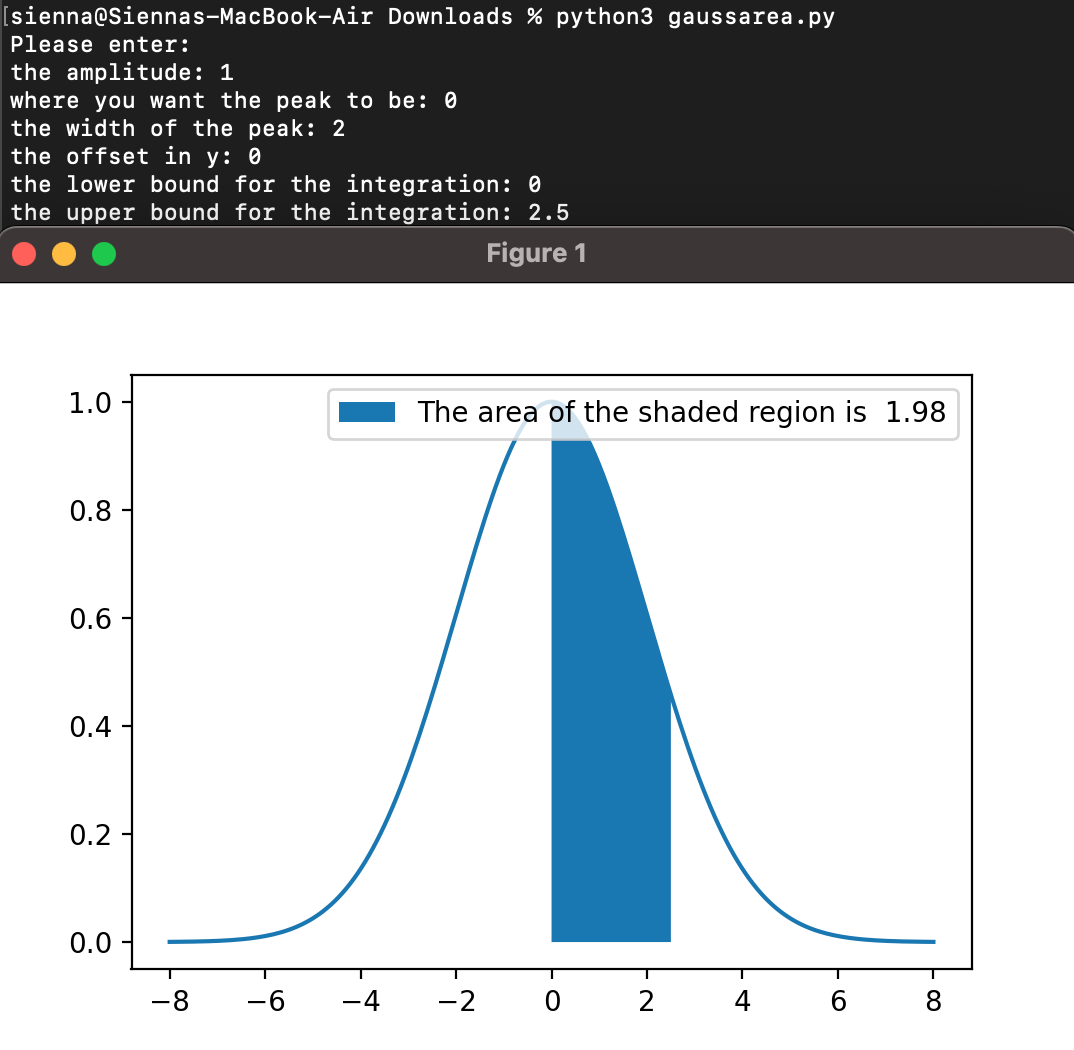

https://github.com/siennajoyahaag-26/PROGNUM-repo/tree/main/Task4

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [6]:
import numpy as np
from numpy import sin, cos, exp, pi
import scipy

fun = input("Please enter the function you wish to integrate over: ")
def a(x):
        return eval(fun)
try:
    # Scipy integration
    integ, e = scipy.integrate.quad(a, 0, pi) # Seperating calculated integral and the error
    print(integ)
    # Monte Carlo integration
    x = np.random.uniform(low=0, high=pi, size=100000) 
    y=eval(fun)
    int2 = sum(y)*(pi-0)/1000
    print(int2)
except NameError:
    print("Make sure you are using x as your variable. If you already are, then the function you have entered is not defined. I can't integrate it for you. ")
except TypeError:
    print("Please use x as your variable.")
except SyntaxError:
    print("Double check your syntax.")
except ZeroDivisionError:
    print("This integral is undefined, as it requires division by 0.")

Please enter the function you wish to integrate over: x
4.934802200544679
496.1089404046466


https://github.com/siennajoyahaag-26/PROGNUM-repo/tree/main/Task4

In [9]:
import sympy as sy
x = sy.Symbol('x') # Defining x as the sympy symbol x
f = input("Please enter the function you wish to integrate over: ")
fun = sy.integrate(f, (x, 0, sy.pi))
print(fun.evalf())

Please enter the function you wish to integrate over:  x**4 + exp(cos(x) + sin(x))


68.7293227268911


In [10]:
# Leave unaltered
totalpoints += 6
currentpoints += 5

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    You need to use a larger N to get accurate results with the Monte Carlo integration
</div>

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

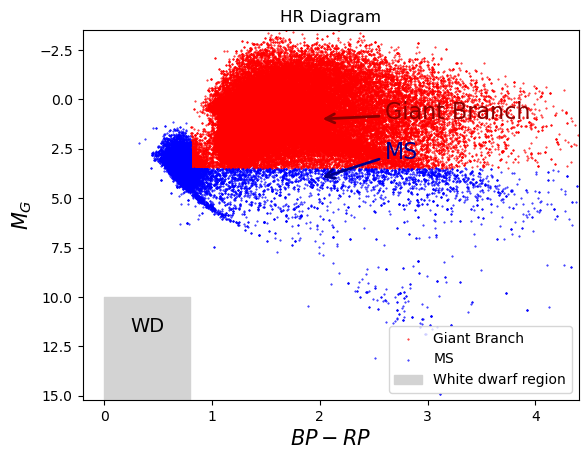

In [11]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

# Sorting data as per the given requirements 
data = data[(data['STARFLAG'] == 0) & (data['ASPCAPFLAG'] == 0) & (data['SNR'] > 0) & (data["GAIAEDR3_PARALLAX"]/ data["GAIAEDR3_PARALLAX_ERROR"] > 5) ]
mask = ~np.isnan(data["GAIAEDR3_PHOT_G_MEAN_MAG"]) | ~np.isnan(data["GAIAEDR3_PHOT_BP_MEAN_MAG"]) | ~np.isnan(data["GAIAEDR3_PHOT_RP_MEAN_MAG"])
# New data
clean_data = data[mask]
ind = np.random.randint(0, len(data), int(0.8*len(data))) # Taking only 80% of the data
less_data = data[ind]

MG = less_data["GAIAEDR3_PHOT_G_MEAN_MAG"]+ 5*np.log10((less_data["GAIAEDR3_PARALLAX"])/1000)+5 # Converting to absolute magnitude
BP_RP = less_data["GAIAEDR3_PHOT_BP_MEAN_MAG"]-less_data["GAIAEDR3_PHOT_RP_MEAN_MAG"] # Calculating BP-RP
mask1 = (MG<3.5) & (BP_RP>0.8) # Mask to seperate MS and Giant Branch

# Giant Branch arrow
plt.annotate("Giant Branch",xy=(2.0, 1.0),xytext=(2.6, 1.0),color='darkred',fontsize=16,arrowprops=dict(arrowstyle='->',color='darkred',lw=2))

# Main Sequence arrow
plt.annotate("MS",xy=(2.0, 4.0),xytext=(2.6, 3.0),color='darkblue',fontsize=16,arrowprops=dict(arrowstyle='->',color='darkblue',lw=2))

# Plotting the seperated sets of data in different colours
plt.scatter(BP_RP[mask1], MG[mask1], label = "Giant Branch", s= 0.2, color= 'r', zorder = 1) # zorder allows the arrows to lie on top of the data
plt.scatter(BP_RP[~mask1], MG[~mask1], label = "MS", s = 0.2, color = 'b', zorder = 1)

# Grey box for white dwarves
wd = np.linspace(0, 0.8, 200) 
plt.fill_between(wd, 10, 16, color ='lightgrey', label = "White dwarf region")
plt.text(0.4, 11.5, "WD", va ='center', ha = 'center', size =14)

plt.xlim(-0.2, 4.4)
plt.ylim(15.2, -3.5) # Y axis goes down to -3.5 to include most of the data points 
plt.legend(loc = "lower right")
plt.title("HR Diagram")
plt.ylabel(r"$M_G$", size=15)
plt.xlabel(r"$BP-RP$", size=15)
plt.show()

In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 23.  Task Grade = 8.8
